# 🔬 QAOA — Quantum Approximate Optimization Algorithm

> *"We introduce a quantum algorithm that produces approximate solutions for combinatorial
> optimization problems. The algorithm depends on a positive integer p and the quality of
> the approximation improves as p is increased."*
> — Farhi, Goldstone & Gutmann (2014)

This notebook provides a rigorous, hands-on introduction to the **Quantum Approximate Optimization
Algorithm (QAOA)** — a hybrid classical-quantum variational algorithm for combinatorial optimization.

**What you will gain:**
- Mathematical foundations: encoding optimization problems as quantum Hamiltonians
- Complete derivation and implementation of the QAOA ansatz from first principles
- Working QAOA solver for the MaxCut problem on small graphs
- Visualization of the variational energy landscape in parameter space
- Analysis of circuit depth scaling and approximation quality
- Connections to adiabatic quantum computation and computational complexity

> **Related notebooks:** For deeper foundations on Hamiltonians and the Ising model, see
> `200_quantum_hamiltonian.ipynb`. For QUBO formulations and problem encodings, see `202_quantum_qubo.ipynb`.

---
### Setup & Imports

*Prerequisites: comfort with superposition, unitaries, and interference (100-series).
Notebook 200 provides optional deeper background on Hamiltonians and the Ising model.*

We use **Qiskit 2.x** with `BasicSimulator` for quantum simulation, **NumPy** for linear algebra,
**Matplotlib** for visualization, and **SciPy** for classical parameter optimization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize as mplNormalize
import random

from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.quantum_info import Statevector, Operator
from scipy.optimize import minimize

backend = BasicSimulator()
SHOTS = 4096
SEED = 42
np.random.seed(SEED)

# ── Core Utility ──────────────────────────────────────────────────────

def maxcut_cost(state_index, edges):
    """Compute MaxCut cost for a computational basis state.

    Args:
        state_index: integer index of the basis state (e.g. 5 = |0101>)
        edges:       list of (i, j) tuples representing graph edges

    Returns:
        Number of edges crossing the partition defined by the bitstring.
    """
    cost = 0
    for (i, j) in edges:
        bi = (state_index >> i) & 1
        bj = (state_index >> j) & 1
        if bi != bj:
            cost += 1
    return cost

# ── Visualization Helpers ─────────────────────────────────────────────

def plot_cost_histogram(counts, edges, n_qubits, title='', ax=None):
    """Bar chart of measurement outcomes colored by MaxCut cost."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(max(8, 2**n_qubits * 0.6), 4))
    all_states = [format(i, f'0{n_qubits}b') for i in range(2**n_qubits)]
    total = sum(counts.values())
    freqs = [counts.get(s, 0) / total for s in all_states]
    costs = [maxcut_cost(int(s, 2), edges) for s in all_states]
    max_cost = max(costs) if costs else 1
    norm = mplNormalize(0, max_cost)
    colors = [cm.RdYlGn(norm(c)) for c in costs]
    bars = ax.bar(all_states, freqs, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Bitstring', fontsize=10)
    ax.set_ylabel('Probability', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks(range(len(all_states)))
    ax.set_xticklabels(all_states, rotation=45, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.25)
    for bar, c, f in zip(bars, costs, freqs):
        if f > 0.005:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'C={c}', ha='center', va='bottom', fontsize=7, fontstyle='italic')
    return ax

print('✅ Setup complete — backend:', type(backend).__name__)

✅ Setup complete — backend: BasicSimulator


---
## Part I — The MaxCut Problem

### §1  Combinatorial Optimization

Many of the most important problems in computer science, logistics, and operations research are
**combinatorial optimization** problems: given a finite set of configurations, find the one that
maximizes (or minimizes) a cost function.

Formally, we seek:

$$\boxed{z^* = \arg\max_{z \in \{0,1\}^n} C(z)}$$

where $C: \{0,1\}^n \to \mathbb{R}$ is the **objective function** and $n$ is the problem size.

Many such problems are **NP-hard** — no known classical algorithm solves them in polynomial time.
This is precisely where quantum algorithms like QAOA offer potential advantage.

### §2  MaxCut: The Canonical Problem

**MaxCut** is the problem of partitioning the vertices of a graph into two sets such that the
number of edges *between* the sets is maximized.

**Definition.** Given an undirected graph $G = (V, E)$ with $|V| = n$ vertices:

- Assign each vertex $i$ a binary variable $z_i \in \{0, 1\}$
- A partition $z = (z_0, z_1, \ldots, z_{n-1})$ assigns each vertex to one of two sets
- An edge $(i, j) \in E$ is **cut** if $z_i \neq z_j$

The objective function is:

$$C(z) = \sum_{(i,j) \in E} \bigl(z_i \oplus z_j\bigr)
       = \sum_{(i,j) \in E} \bigl[z_i(1 - z_j) + z_j(1 - z_i)\bigr]$$

MaxCut is **NP-hard** for general graphs (Karp, 1972), making it an ideal testbed for
quantum optimization algorithms.

C:\Users\bmilanovic\AppData\Local\Temp\ipykernel_46568\2637911020.py:39: UserWarning: Glyph 8324 (\N{SUBSCRIPT FOUR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Dev\azure\quantum-notebook\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8324 (\N{SUBSCRIPT FOUR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


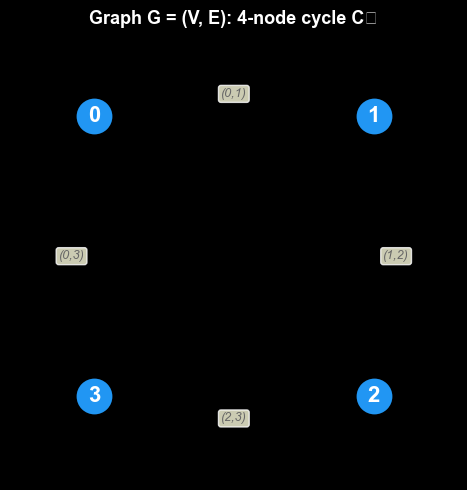

Vertices: [0, 1, 2, 3]
Edges:    [(0, 1), (1, 2), (2, 3), (0, 3)]
This graph has 4 vertices and 4 edges.


In [2]:
# ═══ Define our MaxCut problem: a 4-node cycle graph (C₄) ═════════════

n_qubits = 4
edges = [(0, 1), (1, 2), (2, 3), (0, 3)]

# Node positions for visualization (square layout)
positions = {0: (0, 1), 1: (1, 1), 2: (1, 0), 3: (0, 0)}

fig, ax = plt.subplots(figsize=(5, 5))

# Draw edges
for (i, j) in edges:
    xi, yi = positions[i]
    xj, yj = positions[j]
    ax.plot([xi, xj], [yi, yj], 'k-', linewidth=2.5, zorder=1)

# Draw nodes
for node, (x, y) in positions.items():
    ax.scatter(x, y, s=800, c='#2196F3', zorder=5,
               edgecolors='black', linewidth=2.5)
    ax.text(x, y, str(node), ha='center', va='center',
            fontsize=16, fontweight='bold', color='white', zorder=6)

# Label edges
offsets = {(0, 1): (0, 0.08), (1, 2): (0.08, 0),
           (2, 3): (0, -0.08), (0, 3): (-0.08, 0)}
for (i, j) in edges:
    mx = (positions[i][0] + positions[j][0]) / 2 + offsets[(i, j)][0]
    my = (positions[i][1] + positions[j][1]) / 2 + offsets[(i, j)][1]
    ax.text(mx, my, f'({i},{j})', ha='center', va='center', fontsize=9,
            color='#666', fontstyle='italic',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', alpha=0.8))

ax.set_xlim(-0.3, 1.3)
ax.set_ylim(-0.3, 1.3)
ax.set_aspect('equal')
ax.set_title('Graph G = (V, E): 4-node cycle C\u2084', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f'Vertices: {list(range(n_qubits))}')
print(f'Edges:    {edges}')
print(f'This graph has {n_qubits} vertices and {len(edges)} edges.')

### §3  Classical Brute-Force Solution

For small graphs we can enumerate all $2^n$ partitions and compute the cost of each.
This gives us the **exact** optimal solution to compare against QAOA.

For the cycle graph $C_4$ we expect the maximum cut to be **4** — achieved by alternating
vertices across the two partitions (the "checkerboard" pattern).

Optimal MaxCut value: 4
Optimal partitions:
  |0101⟩  →  S₀=[1, 3], S₁=[0, 2]  (cost=4)
  |1010⟩  →  S₀=[0, 2], S₁=[1, 3]  (cost=4)


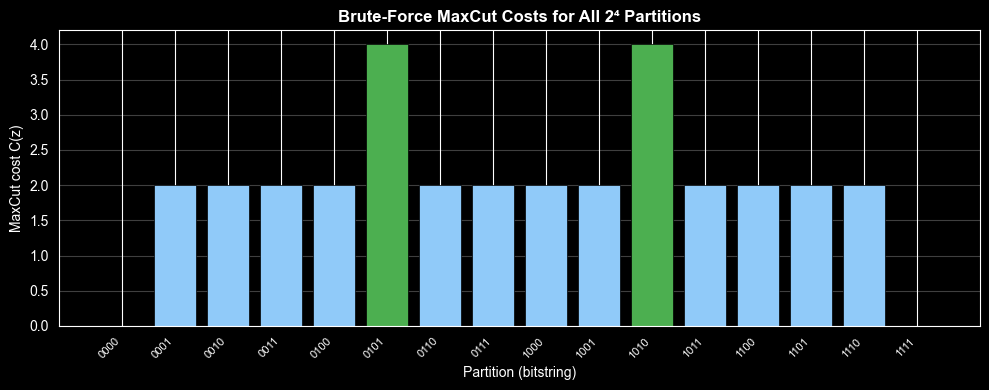


Green bars = optimal partitions (cost = 4)


In [3]:
# ═══ Brute-force: enumerate all 2ⁿ partitions ═════════════════════════

def brute_force_maxcut(n_qubits, edges):
    """Find optimal MaxCut by exhaustive enumeration."""
    best_cost = 0
    best_states = []
    all_costs = []
    for z in range(2**n_qubits):
        cost = maxcut_cost(z, edges)
        all_costs.append(cost)
        if cost > best_cost:
            best_cost = cost
            best_states = [z]
        elif cost == best_cost:
            best_states.append(z)
    return best_cost, best_states, all_costs

optimal_cost, optimal_states, all_costs = brute_force_maxcut(n_qubits, edges)

print(f'Optimal MaxCut value: {optimal_cost}')
print(f'Optimal partitions:')
for s in optimal_states:
    bs = format(s, f'0{n_qubits}b')
    s0 = [i for i in range(n_qubits) if (s >> i) & 1 == 0]
    s1 = [i for i in range(n_qubits) if (s >> i) & 1 == 1]
    print(f'  |{bs}\u27e9  \u2192  S\u2080={s0}, S\u2081={s1}  (cost={optimal_cost})')

# Visualize all costs
fig, ax = plt.subplots(figsize=(10, 4))
labels = [format(i, f'0{n_qubits}b') for i in range(2**n_qubits)]
colors = ['#4CAF50' if i in optimal_states else '#90CAF9'
          for i in range(2**n_qubits)]
ax.bar(labels, all_costs, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Partition (bitstring)', fontsize=10)
ax.set_ylabel('MaxCut cost C(z)', fontsize=10)
ax.set_title('Brute-Force MaxCut Costs for All 2\u2074 Partitions',
             fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.25)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

print(f'\nGreen bars = optimal partitions (cost = {optimal_cost})')

---
## Part II — From Classical Cost to Quantum Hamiltonian

### §4  The Ising Encoding

The key insight of quantum optimization is encoding classical cost functions as **quantum
Hamiltonians** whose eigenvalues are the cost values.

**Spin mapping.** Replace each binary variable $z_i \in \{0, 1\}$ with the Pauli-$Z$ operator $Z_i$
whose eigenvalues $\pm 1$ correspond to the computational basis:

$$Z_i|0\rangle = +|0\rangle, \qquad Z_i|1\rangle = -|1\rangle$$

**Edge term.** For an edge $(i, j)$, the operator $\tfrac{1}{2}(I - Z_i Z_j)$ has eigenvalue:

| Qubit $i$ | Qubit $j$ | $Z_i Z_j$ | $\frac{1}{2}(I - Z_i Z_j)$ | Edge cut? |
|:---------:|:---------:|:---------:|:---------------------------:|:---------:|
| $\|0\rangle$ | $\|0\rangle$ | $+1$ | $0$ | No |
| $\|0\rangle$ | $\|1\rangle$ | $-1$ | $1$ | **Yes** |
| $\|1\rangle$ | $\|0\rangle$ | $-1$ | $1$ | **Yes** |
| $\|1\rangle$ | $\|1\rangle$ | $+1$ | $0$ | No |

### §5  The Cost Hamiltonian

The **cost Hamiltonian** $\hat{C}$ is a diagonal operator whose eigenvalues equal the MaxCut cost:

$$\boxed{\hat{C} = \sum_{(i,j) \in E} \frac{1}{2}\bigl(I - Z_i Z_j\bigr)}$$

**Key properties:**
- $\hat{C}$ is **diagonal** in the computational basis: $\hat{C}\,|z\rangle = C(z)\,|z\rangle$
- The eigenstates are the computational basis states $\{|z\rangle\}$
- The eigenvalues are the classical MaxCut costs $\{C(z)\}$
- **Maximizing** $\langle\psi|\hat{C}|\psi\rangle$ over quantum states gives the optimal MaxCut value

### §6  The Mixer Hamiltonian

The **mixer Hamiltonian** generates transitions between computational basis states:

$$\boxed{\hat{B} = \sum_{i=0}^{n-1} X_i}$$

While $\hat{C}$ encodes *which solutions are good*, $\hat{B}$ enables **exploration** by flipping
individual qubits. The interplay between $\hat{C}$ and $\hat{B}$ drives QAOA toward
optimal solutions through constructive interference.

In [4]:
# ═══ Construct the cost Hamiltonian matrix and verify ═══════════════

I2 = np.eye(2)
Z = np.array([[1, 0], [0, -1]])

def kron_n(*matrices):
    """Tensor product of an arbitrary number of matrices."""
    result = matrices[0]
    for m in matrices[1:]:
        result = np.kron(result, m)
    return result

def zz_operator(i, j, n):
    """Construct Z_i \u2297 Z_j on n qubits."""
    ops = [I2] * n
    ops[i] = Z
    ops[j] = Z
    return kron_n(*ops)

# Build C = Σ_{(i,j)} (I - Z_i Z_j) / 2
dim = 2**n_qubits
C_matrix = np.zeros((dim, dim))
for (i, j) in edges:
    C_matrix += (np.eye(dim) - zz_operator(i, j, n_qubits)) / 2

# Verify: C is diagonal and eigenvalues = MaxCut costs
assert np.allclose(C_matrix, np.diag(np.diag(C_matrix))), "C must be diagonal!"

print("Cost Hamiltonian eigenvalues vs brute-force MaxCut costs:")
print(f"{'State':>8} {'Eigenvalue':>12} {'MaxCut cost':>12} {'Match':>8}")
print("-" * 44)
all_match = True
for k in range(dim):
    eigenval = C_matrix[k, k]
    cost = maxcut_cost(k, edges)
    match = abs(eigenval - cost) < 1e-10
    all_match = all_match and match
    marker = '\u2713' if match else '\u2717'
    print(f"|{format(k, f'0{n_qubits}b')}\u27e9 {eigenval:>12.1f} {cost:>12} {marker:>8}")

assert all_match, "Hamiltonian eigenvalues must equal MaxCut costs!"
print(f"\n\u2705 Cost Hamiltonian verified: all {dim} eigenvalues match classical costs.")
print(f"   Maximum eigenvalue = {np.max(np.diag(C_matrix)):.0f} = optimal MaxCut value")

Cost Hamiltonian eigenvalues vs brute-force MaxCut costs:
   State   Eigenvalue  MaxCut cost    Match
--------------------------------------------
|0000⟩          0.0            0        ✓
|0001⟩          2.0            2        ✓
|0010⟩          2.0            2        ✓
|0011⟩          2.0            2        ✓
|0100⟩          2.0            2        ✓
|0101⟩          4.0            4        ✓
|0110⟩          2.0            2        ✓
|0111⟩          2.0            2        ✓
|1000⟩          2.0            2        ✓
|1001⟩          2.0            2        ✓
|1010⟩          4.0            4        ✓
|1011⟩          2.0            2        ✓
|1100⟩          2.0            2        ✓
|1101⟩          2.0            2        ✓
|1110⟩          2.0            2        ✓
|1111⟩          0.0            0        ✓

✅ Cost Hamiltonian verified: all 16 eigenvalues match classical costs.
   Maximum eigenvalue = 4 = optimal MaxCut value


---
## Part III — The QAOA Ansatz

### §7  Variational Quantum Algorithm Structure

QAOA is a **variational** (hybrid) quantum algorithm:
1. A **quantum computer** evaluates a parameterized cost function
2. A **classical optimizer** searches for the best parameters
3. Steps 1–2 repeat until convergence

### §8  The QAOA Circuit

The QAOA ansatz at depth $p$ prepares the state:

$$\boxed{|\boldsymbol{\gamma}, \boldsymbol{\beta}\rangle
   = \underbrace{e^{-i\beta_p \hat{B}} \, e^{-i\gamma_p \hat{C}}}_{\text{round } p}
     \cdots
     \underbrace{e^{-i\beta_1 \hat{B}} \, e^{-i\gamma_1 \hat{C}}}_{\text{round } 1}
     \, |{+}\rangle^{\otimes n}}$$

where:
- $\boldsymbol{\gamma} = (\gamma_1, \ldots, \gamma_p) \in [0, 2\pi)^p$ — **cost parameters**
- $\boldsymbol{\beta} = (\beta_1, \ldots, \beta_p) \in [0, \pi)^p$ — **mixer parameters**
- $|{+}\rangle^{\otimes n} = H^{\otimes n}|0\rangle^{\otimes n}
  = \frac{1}{\sqrt{2^n}}\sum_{z=0}^{2^n-1}|z\rangle$ — uniform superposition

### §9  Gate-Level Decomposition

**Cost unitary** $U_C(\gamma) = e^{-i\gamma \hat{C}}$:

Since $\hat{C} = \sum_{(i,j)} \frac{1}{2}(I - Z_iZ_j)$ and all terms commute (diagonal), we decompose:

$$U_C(\gamma) = \prod_{(i,j) \in E} e^{-i\gamma(I - Z_iZ_j)/2}
             = \prod_{(i,j) \in E} \underbrace{e^{-i\gamma/2}}_{\text{global phase}} \cdot e^{i\gamma Z_iZ_j/2}$$

The $ZZ$-rotation $e^{i\gamma Z_iZ_j/2}$ is implemented via the standard decomposition:

$$\text{CNOT}(i,j) \;\to\; R_z(-\gamma,\; j) \;\to\; \text{CNOT}(i,j)$$

*Proof:* The sequence $\text{CNOT} \cdot R_z(\theta) \cdot \text{CNOT}$ produces
$e^{-i(\theta/2)\, Z_i Z_j}$. Setting $\theta = -\gamma$ gives
$e^{i(\gamma/2)\, Z_iZ_j}$ as required. $\square$

**Mixer unitary** $U_B(\beta) = e^{-i\beta \hat{B}}$:

Since $\hat{B} = \sum_i X_i$ and the terms act on different qubits (commute):

$$U_B(\beta) = \prod_{i=0}^{n-1} e^{-i\beta X_i} = \prod_{i=0}^{n-1} R_x(2\beta,\; i)$$

### §10  The Variational Principle

The objective is to find parameters that **maximize**:

$$F_p(\boldsymbol{\gamma}, \boldsymbol{\beta})
  = \langle\boldsymbol{\gamma}, \boldsymbol{\beta}|\,\hat{C}\,|\boldsymbol{\gamma}, \boldsymbol{\beta}\rangle
  = \sum_{z=0}^{2^n-1} |\langle z | \boldsymbol{\gamma}, \boldsymbol{\beta}\rangle|^2 \cdot C(z)$$

The variational principle guarantees $\max F_p \leq C_{\max}$, with equality achievable
as $p \to \infty$ (the circuit can approximate any state in the limit).

The **approximation ratio** is:

$$r_p = \frac{\max F_p}{C_{\max}} \in [0, 1]$$

In [5]:
# ═══ Build the QAOA circuit ═════════════════════════════════════════

def build_qaoa_circuit(n_qubits, edges, gammas, betas, measure=False):
    """Construct a QAOA circuit for MaxCut.

    Args:
        n_qubits: Number of qubits (= number of graph vertices)
        edges:    List of (i, j) edge tuples
        gammas:   List of p cost parameters \u03b3\u2081, ..., \u03b3_p
        betas:    List of p mixer parameters \u03b2\u2081, ..., \u03b2_p
        measure:  If True, add measurement gates

    Returns:
        QuantumCircuit implementing the QAOA ansatz
    """
    p = len(gammas)
    assert len(betas) == p, "gammas and betas must have same length"

    if measure:
        qc = QuantumCircuit(n_qubits, n_qubits)
    else:
        qc = QuantumCircuit(n_qubits)

    # Initial state: |+\u27e9^{\u2297n}
    for i in range(n_qubits):
        qc.h(i)

    for l in range(p):
        qc.barrier()

        # Cost unitary U_C(\u03b3_l)
        for (i, j) in edges:
            qc.cx(i, j)
            qc.rz(-gammas[l], j)
            qc.cx(i, j)

        qc.barrier()

        # Mixer unitary U_B(\u03b2_l)
        for i in range(n_qubits):
            qc.rx(2 * betas[l], i)

    if measure:
        qc.barrier()
        qc.measure(range(n_qubits), range(n_qubits))

    return qc

print("\u2705 QAOA circuit builder defined")

✅ QAOA circuit builder defined


In [6]:
# ═══ Visualize an example QAOA circuit (p=1) ═══════════════════════

example_qc = build_qaoa_circuit(n_qubits, edges,
                                 gammas=[np.pi/4],
                                 betas=[np.pi/8],
                                 measure=True)

print("QAOA circuit for MaxCut on C\u2084 (p=1, \u03b3=\u03c0/4, \u03b2=\u03c0/8):")
print()
print(example_qc.draw(output='text', fold=120))
print(f"\nCircuit depth: {example_qc.depth()}")
print(f"Gate count:    {dict(example_qc.count_ops())}")

QAOA circuit for MaxCut on C₄ (p=1, γ=π/4, β=π/8):

     ┌───┐ ░                                                                                          ░ ┌─────────┐ ░ »
q_0: ┤ H ├─░───■────────────────■────────────────────────────────────────────────■────────────────■───░─┤ Rx(π/4) ├─░─»
     ├───┤ ░ ┌─┴─┐┌──────────┐┌─┴─┐                                              │                │   ░ ├─────────┤ ░ »
q_1: ┤ H ├─░─┤ X ├┤ Rz(-π/4) ├┤ X ├──■────────────────■──────────────────────────┼────────────────┼───░─┤ Rx(π/4) ├─░─»
     ├───┤ ░ └───┘└──────────┘└───┘┌─┴─┐┌──────────┐┌─┴─┐                        │                │   ░ ├─────────┤ ░ »
q_2: ┤ H ├─░───────────────────────┤ X ├┤ Rz(-π/4) ├┤ X ├──■────────────────■────┼────────────────┼───░─┤ Rx(π/4) ├─░─»
     ├───┤ ░                       └───┘└──────────┘└───┘┌─┴─┐┌──────────┐┌─┴─┐┌─┴─┐┌──────────┐┌─┴─┐ ░ ├─────────┤ ░ »
q_3: ┤ H ├─░─────────────────────────────────────────────┤ X ├┤ Rz(-π/4) ├┤ X ├┤ X ├┤ Rz(-π/4) ├┤ X ├─░─┤ Rx

---
## Part IV — Running QAOA

### §11  Computing the Cost Expectation Value

Given QAOA parameters $(\boldsymbol{\gamma}, \boldsymbol{\beta})$, we compute:

$$F_p(\boldsymbol{\gamma}, \boldsymbol{\beta})
  = \sum_{z} P(z) \cdot C(z)
  = \sum_{z} |\langle z | \boldsymbol{\gamma}, \boldsymbol{\beta}\rangle|^2 \cdot C(z)$$

Two evaluation methods:
1. **Exact** (via `Statevector`): analytically compute probabilities — no sampling noise
2. **Empirical** (via shots): run the circuit many times and estimate from measurement statistics

### §12  The Classical Optimization Loop

QAOA is a **hybrid** algorithm: the quantum computer evaluates $F_p$, and a classical
optimizer searches for parameters that maximize it:

$$(\boldsymbol{\gamma}^*, \boldsymbol{\beta}^*)
  = \arg\max_{\boldsymbol{\gamma}, \boldsymbol{\beta}} F_p(\boldsymbol{\gamma}, \boldsymbol{\beta})$$

We use **COBYLA** (Constrained Optimization BY Linear Approximation), a derivative-free
optimizer well-suited for noisy quantum cost landscapes.

In [7]:
# ═══ Cost evaluation functions ════════════════════════════════════

def qaoa_expectation_exact(gammas, betas, n_qubits, edges):
    """Compute \u27e8\u03b3,\u03b2|C|\u03b3,\u03b2\u27e9 using exact statevector simulation."""
    qc = build_qaoa_circuit(n_qubits, edges, gammas, betas, measure=False)
    sv = Statevector.from_instruction(qc)
    probs = sv.probabilities()
    return sum(probs[z] * maxcut_cost(z, edges) for z in range(len(probs)))

def qaoa_expectation_shots(gammas, betas, n_qubits, edges, shots=SHOTS, seed=SEED):
    """Compute \u27e8\u03b3,\u03b2|C|\u03b3,\u03b2\u27e9 using shot-based simulation."""
    qc = build_qaoa_circuit(n_qubits, edges, gammas, betas, measure=True)
    compiled = transpile(qc, backend, seed_transpiler=seed)
    result = backend.run(compiled, shots=shots, seed_simulator=seed).result()
    counts = result.get_counts()
    total = sum(counts.values())
    expectation = sum((count / total) * maxcut_cost(int(bs, 2), edges)
                      for bs, count in counts.items())
    return expectation, counts

# ── Sanity check: \u03b3=0, \u03b2=0 should give uniform superposition ─────────
avg_cost = sum(all_costs) / len(all_costs)
qaoa_uniform = qaoa_expectation_exact([0.0], [0.0], n_qubits, edges)
print(f"Average cost over all partitions: {avg_cost:.4f}")
print(f"QAOA at (\u03b3=0, \u03b2=0) [\u2248 uniform]:  {qaoa_uniform:.4f}")

assert abs(qaoa_uniform - avg_cost) < 1e-6, "Zero parameters should give uniform superposition"
print("\u2705 Expectation value computation verified")

Average cost over all partitions: 2.0000
QAOA at (γ=0, β=0) [≈ uniform]:  2.0000
✅ Expectation value computation verified


In [8]:
# ═══ Optimize QAOA parameters ════════════════════════════════════

def run_qaoa(n_qubits, edges, p, method='COBYLA', maxiter=500, seed=None):
    """Run the full QAOA classical-quantum optimization loop."""
    history = []

    def objective(params):
        gammas = list(params[:p])
        betas = list(params[p:])
        cost = qaoa_expectation_exact(gammas, betas, n_qubits, edges)
        history.append(cost)
        return -cost   # minimize negative cost = maximize cost

    # Initial parameters: small random values in a promising range
    rng = np.random.default_rng(seed)
    x0 = rng.uniform(0.01, 1.0, size=2 * p)

    result = minimize(objective, x0, method=method,
                      options={'maxiter': maxiter, 'rhobeg': 0.5})

    opt_gammas = list(result.x[:p])
    opt_betas = list(result.x[p:])
    opt_cost = -result.fun

    return {
        'gammas': opt_gammas,
        'betas': opt_betas,
        'cost': opt_cost,
        'history': history,
        'n_eval': len(history),
        'scipy_result': result
    }

# ── Run QAOA at p=1 ──────────────────────────────────────────────────
print("Running QAOA optimization (p=1) ...")
qaoa_p1 = run_qaoa(n_qubits, edges, p=1, seed=SEED)

print(f"\n{'='*50}")
print(f"QAOA Result (p=1)")
print(f"{'='*50}")
print(f"Optimal \u03b3\u2081:          {qaoa_p1['gammas'][0]:.6f}")
print(f"Optimal \u03b2\u2081:          {qaoa_p1['betas'][0]:.6f}")
print(f"Expected cost (exact): {qaoa_p1['cost']:.6f}")
print(f"Optimal MaxCut value:  {optimal_cost}")
print(f"Approximation ratio:   {qaoa_p1['cost'] / optimal_cost:.6f}")
print(f"Function evaluations:  {qaoa_p1['n_eval']}")

Running QAOA optimization (p=1) ...

QAOA Result (p=1)
Optimal γ₁:          0.785447
Optimal β₁:          0.392777
Expected cost (exact): 3.000000
Optimal MaxCut value:  4
Approximation ratio:   0.750000
Function evaluations:  34


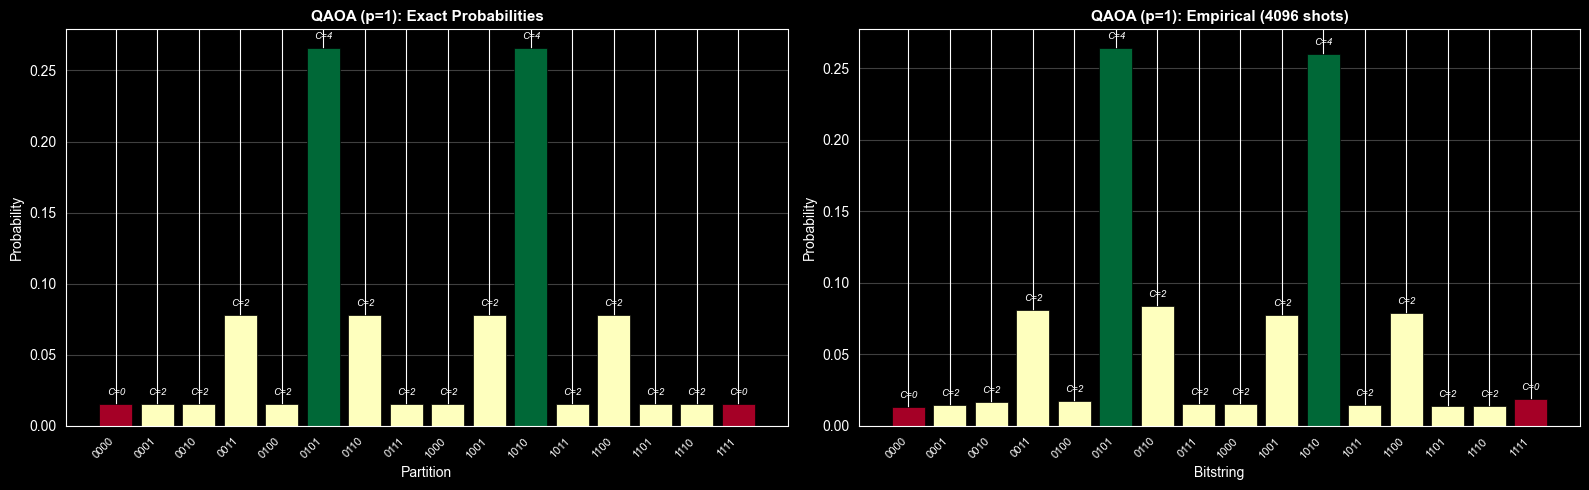


Top measured outcomes:
  |0101⟩  freq=0.264  cost=4  ⭐ OPTIMAL
  |1010⟩  freq=0.260  cost=4  ⭐ OPTIMAL
  |0110⟩  freq=0.084  cost=2  
  |0011⟩  freq=0.081  cost=2  
  |1100⟩  freq=0.079  cost=2  
  |1001⟩  freq=0.077  cost=2  


In [9]:
# ═══ Analyze the optimized QAOA output ════════════════════════════

opt_g, opt_b = qaoa_p1['gammas'], qaoa_p1['betas']

# Exact probability distribution
qc_opt = build_qaoa_circuit(n_qubits, edges, opt_g, opt_b, measure=False)
sv_opt = Statevector.from_instruction(qc_opt)
probs_opt = sv_opt.probabilities()

# Shot-based distribution
_, counts_opt = qaoa_expectation_shots(opt_g, opt_b, n_qubits, edges)

# ── Visualization ─────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

all_labels = [format(i, f'0{n_qubits}b') for i in range(2**n_qubits)]
costs_all = [maxcut_cost(i, edges) for i in range(2**n_qubits)]
max_c = max(costs_all)
norm = mplNormalize(0, max_c)
colors = [cm.RdYlGn(norm(c)) for c in costs_all]

# Left: exact
bars1 = ax1.bar(all_labels, probs_opt, color=colors, edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Partition', fontsize=10)
ax1.set_ylabel('Probability', fontsize=10)
ax1.set_title('QAOA (p=1): Exact Probabilities', fontsize=11, fontweight='bold')
ax1.set_xticks(range(len(all_labels)))
ax1.set_xticklabels(all_labels, rotation=45, ha='right', fontsize=8)
ax1.grid(axis='y', alpha=0.25)
for bar, c, pv in zip(bars1, costs_all, probs_opt):
    if pv > 0.01:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'C={c}', ha='center', va='bottom', fontsize=7, fontstyle='italic')

# Right: empirical
plot_cost_histogram(counts_opt, edges, n_qubits,
                    title=f'QAOA (p=1): Empirical ({SHOTS} shots)', ax=ax2)

plt.tight_layout()
plt.show()

# ── Top outcomes ──────────────────────────────────────────────────────
print("\nTop measured outcomes:")
sorted_counts = sorted(counts_opt.items(), key=lambda x: x[1], reverse=True)
for bs, count in sorted_counts[:6]:
    z = int(bs, 2)
    cost = maxcut_cost(z, edges)
    tag = "\u2b50 OPTIMAL" if cost == optimal_cost else ""
    print(f"  |{bs}\u27e9  freq={count/SHOTS:.3f}  cost={cost}  {tag}")

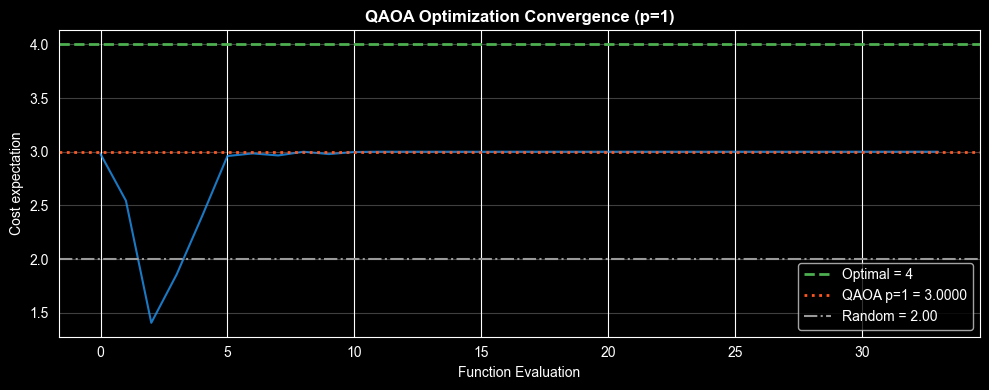

✅ QAOA p=1 beats random guessing: 3.0000 > 2.0000
✅ Approximation ratio: 0.7500 (> 0.6)
✅ Empirical matches exact: |2.9854 - 3.0000| < 0.3


In [10]:
# ═══ Optimization convergence and validation ═════════════════════

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(qaoa_p1['history'], color='#2196F3', linewidth=1.5, alpha=0.8)
ax.axhline(y=optimal_cost, color='#4CAF50', linestyle='--', linewidth=2,
           label=f'Optimal = {optimal_cost}')
ax.axhline(y=qaoa_p1['cost'], color='#FF5722', linestyle=':', linewidth=2,
           label=f'QAOA p=1 = {qaoa_p1["cost"]:.4f}')
ax.axhline(y=avg_cost, color='#999', linestyle='-.',
           label=f'Random = {avg_cost:.2f}')
ax.set_xlabel('Function Evaluation', fontsize=10)
ax.set_ylabel('Cost expectation', fontsize=10)
ax.set_title('QAOA Optimization Convergence (p=1)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

# ── Validation asserts ────────────────────────────────────────────────
approx_ratio_p1 = qaoa_p1['cost'] / optimal_cost

assert qaoa_p1['cost'] > avg_cost, \
    f"QAOA must beat random guessing: {qaoa_p1['cost']:.4f} <= {avg_cost:.4f}"
assert approx_ratio_p1 > 0.6, \
    f"p=1 approximation ratio too low: {approx_ratio_p1:.4f}"

# Verify shot-based expectation is close to exact
emp_cost, _ = qaoa_expectation_shots(opt_g, opt_b, n_qubits, edges)
assert abs(emp_cost - qaoa_p1['cost']) < 0.3, \
    f"Empirical cost {emp_cost:.4f} too far from exact {qaoa_p1['cost']:.4f}"

print(f"\u2705 QAOA p=1 beats random guessing: {qaoa_p1['cost']:.4f} > {avg_cost:.4f}")
print(f"\u2705 Approximation ratio: {approx_ratio_p1:.4f} (> 0.6)")
print(f"\u2705 Empirical matches exact: |{emp_cost:.4f} - {qaoa_p1['cost']:.4f}| < 0.3")

---
## Part V — The Energy Landscape

### §13  Visualizing the Parameter Space

For $p = 1$ QAOA, the cost function $F_1(\gamma, \beta)$ is a 2D surface that we can
visualize directly. This landscape reveals the **structure** of the optimization problem:

- **Periodicity**: $F_1(\gamma, \beta)$ is periodic in $\gamma$ with period $2\pi$ and in $\beta$
  with period $\pi$ (since $R_x(2\beta)$ has period $\pi$ in $\beta$)
- **Symmetry**: $F_1(\gamma, \beta) = F_1(-\gamma, -\beta)$ (time-reversal symmetry)
- **Local maxima**: the landscape may have multiple local optima, making classical
  optimization non-trivial even for $p = 1$

Scanning 60×60 = 3600 parameter points ...


C:\Users\bmilanovic\AppData\Local\Temp\ipykernel_46568\1334976913.py:38: UserWarning: Glyph 8324 (\N{SUBSCRIPT FOUR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\bmilanovic\AppData\Local\Temp\ipykernel_46568\1334976913.py:38: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Dev\azure\quantum-notebook\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8324 (\N{SUBSCRIPT FOUR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Dev\azure\quantum-notebook\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


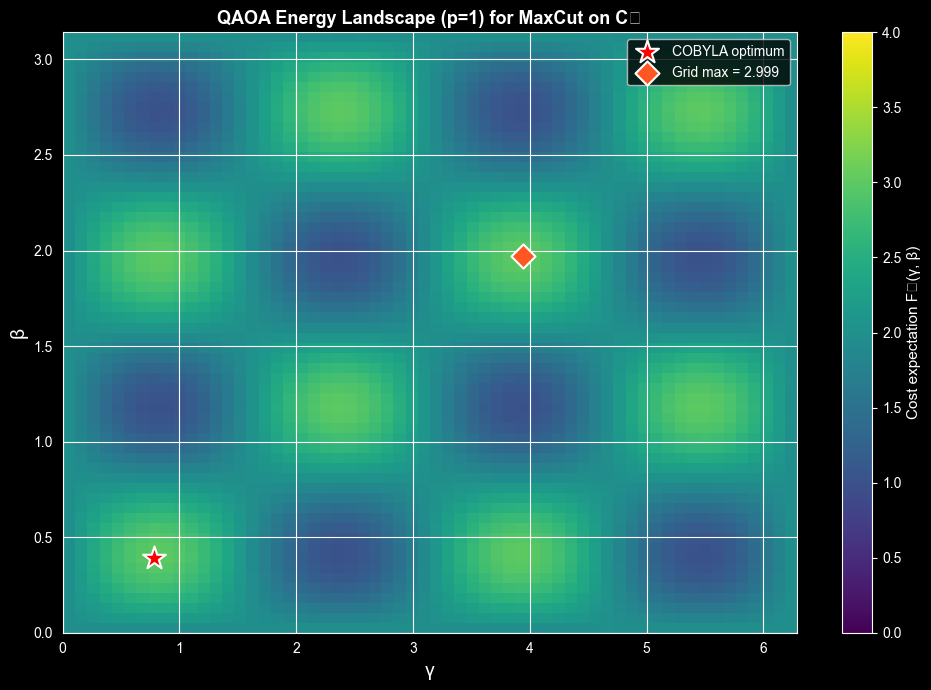

Landscape range: [1.0007, 2.9993]
Grid maximum at γ=3.9403, β=1.9702
COBYLA optimum:  γ=0.7854, β=0.3928


In [11]:
# ═══ 2D Energy Landscape for p=1 ══════════════════════════════════

n_grid = 60
gamma_range = np.linspace(0, 2 * np.pi, n_grid)
beta_range = np.linspace(0, np.pi, n_grid)

print(f"Scanning {n_grid}\u00d7{n_grid} = {n_grid**2} parameter points ...")
landscape = np.zeros((n_grid, n_grid))
for i, beta in enumerate(beta_range):
    for j, gamma in enumerate(gamma_range):
        landscape[i, j] = qaoa_expectation_exact([gamma], [beta], n_qubits, edges)

# ── Heatmap ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(landscape, extent=[0, 2*np.pi, 0, np.pi],
               aspect='auto', origin='lower', cmap='viridis',
               vmin=0, vmax=optimal_cost)

# Mark the optimizer's solution
ax.scatter([qaoa_p1['gammas'][0] % (2*np.pi)],
           [qaoa_p1['betas'][0] % np.pi],
           marker='*', s=300, c='red', edgecolors='white', linewidth=1.5,
           zorder=5, label='COBYLA optimum')

# Mark the global maximum
max_idx = np.unravel_index(np.argmax(landscape), landscape.shape)
ax.scatter([gamma_range[max_idx[1]]], [beta_range[max_idx[0]]],
           marker='D', s=150, c='#FF5722', edgecolors='white', linewidth=1.5,
           zorder=5, label=f'Grid max = {landscape[max_idx]:.3f}')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Cost expectation F\u2081(\u03b3, \u03b2)', fontsize=11)
ax.set_xlabel('\u03b3', fontsize=14)
ax.set_ylabel('\u03b2', fontsize=14)
ax.set_title('QAOA Energy Landscape (p=1) for MaxCut on C\u2084',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()

print(f"Landscape range: [{landscape.min():.4f}, {landscape.max():.4f}]")
print(f"Grid maximum at \u03b3={gamma_range[max_idx[1]]:.4f}, \u03b2={beta_range[max_idx[0]]:.4f}")
print(f"COBYLA optimum:  \u03b3={qaoa_p1['gammas'][0]:.4f}, \u03b2={qaoa_p1['betas'][0]:.4f}")

---
## Part VI — Depth Scaling: Increasing $p$

### §14  Deeper Circuits Improve Approximation

A fundamental result in QAOA theory:

> **Theorem** (Farhi et al., 2014). For any combinatorial optimization problem, the QAOA
> approximation ratio $r_p$ is **non-decreasing** in $p$:
> $$r_1 \leq r_2 \leq \cdots \leq r_p \leq \cdots \leq 1$$
> Moreover, $\lim_{p \to \infty} r_p = 1$ (the exact solution is recovered).

At higher $p$, the circuit has more free parameters ($2p$ total) and can express more
complex interference patterns. The tradeoff: more parameters mean a harder classical
optimization problem and deeper quantum circuits (more susceptible to noise).

Running QAOA (p=1) ... cost = 3.0000, ratio = 0.7500
Running QAOA (p=2) ... cost = 4.0000, ratio = 1.0000
Running QAOA (p=3) ... cost = 4.0000, ratio = 1.0000


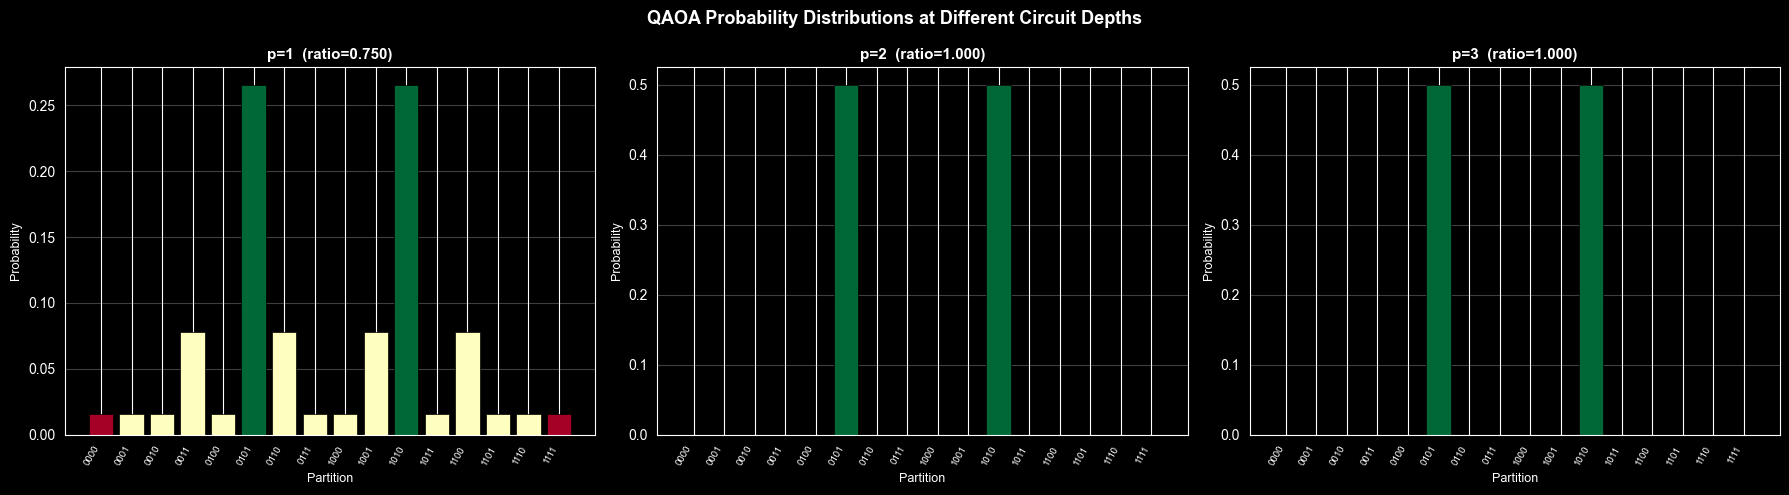


  p       Cost      Ratio   Params    Evals
--------------------------------------------
  1     3.0000     0.7500        2       54
  2     4.0000     1.0000        4      117
  3     4.0000     1.0000        6      124

Optimal MaxCut = 4


In [12]:
# ═══ Run QAOA for p = 1, 2, 3 and compare ════════════════════════

p_values = [1, 2, 3]
qaoa_results = {}

for p in p_values:
    print(f"Running QAOA (p={p}) ... ", end="", flush=True)
    # Run multiple restarts to avoid local optima
    best = None
    for trial in range(5):
        res = run_qaoa(n_qubits, edges, p=p, seed=SEED + trial * 100)
        if best is None or res['cost'] > best['cost']:
            best = res
    qaoa_results[p] = best
    ratio = best['cost'] / optimal_cost
    print(f"cost = {best['cost']:.4f}, ratio = {ratio:.4f}")

# ── Visualization ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, p in zip(axes, p_values):
    res = qaoa_results[p]
    qc = build_qaoa_circuit(n_qubits, edges, res['gammas'], res['betas'], measure=False)
    sv = Statevector.from_instruction(qc)
    probs = sv.probabilities()

    labels = [format(i, f'0{n_qubits}b') for i in range(2**n_qubits)]
    costs_c = [maxcut_cost(i, edges) for i in range(2**n_qubits)]
    norm = mplNormalize(0, max(costs_c))
    colors = [cm.RdYlGn(norm(c)) for c in costs_c]

    ax.bar(labels, probs, color=colors, edgecolor='black', linewidth=0.5)
    ratio = res['cost'] / optimal_cost
    ax.set_title(f'p={p}  (ratio={ratio:.3f})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Partition', fontsize=9)
    ax.set_ylabel('Probability', fontsize=9)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=60, ha='right', fontsize=7)
    ax.grid(axis='y', alpha=0.25)

fig.suptitle('QAOA Probability Distributions at Different Circuit Depths',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────
print(f"\n{'p':>3} {'Cost':>10} {'Ratio':>10} {'Params':>8} {'Evals':>8}")
print("-" * 44)
for p in p_values:
    res = qaoa_results[p]
    ratio = res['cost'] / optimal_cost
    print(f"{p:>3} {res['cost']:>10.4f} {ratio:>10.4f} {2*p:>8} {res['n_eval']:>8}")
print(f"\nOptimal MaxCut = {optimal_cost}")

C:\Users\bmilanovic\AppData\Local\Temp\ipykernel_46568\3463356064.py:31: UserWarning: Glyph 8346 (\N{LATIN SUBSCRIPT SMALL LETTER P}) missing from font(s) Arial.
  plt.tight_layout()
C:\Dev\azure\quantum-notebook\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8346 (\N{LATIN SUBSCRIPT SMALL LETTER P}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


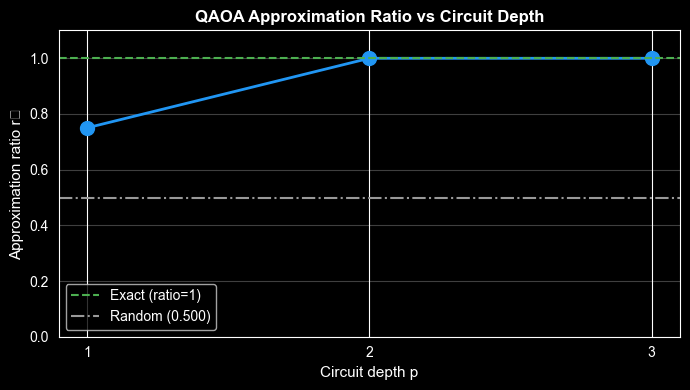

✅ Depth scaling validated: ratios = ['0.7500', '1.0000', '1.0000']
✅ All depths beat random guessing


In [13]:
# ═══ Validate depth scaling ══════════════════════════════════════

# Approximation ratio should be non-decreasing with p
ratios = [qaoa_results[p]['cost'] / optimal_cost for p in p_values]
for i in range(1, len(ratios)):
    assert ratios[i] >= ratios[i-1] - 0.05, \
        f"Ratio at p={p_values[i]} ({ratios[i]:.4f}) should not be much worse than p={p_values[i-1]} ({ratios[i-1]:.4f})"

# All results should beat random
for p in p_values:
    assert qaoa_results[p]['cost'] > avg_cost, \
        f"QAOA p={p} must beat random: {qaoa_results[p]['cost']:.4f} <= {avg_cost:.4f}"

# Higher p should have reasonable approximation
assert ratios[-1] > 0.7, \
    f"p={p_values[-1]} approximation ratio too low: {ratios[-1]:.4f}"

# Visualize the ratio trend
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(p_values, ratios, 'o-', color='#2196F3', linewidth=2, markersize=10)
ax.axhline(y=1.0, color='#4CAF50', linestyle='--', linewidth=1.5, label='Exact (ratio=1)')
ax.axhline(y=avg_cost/optimal_cost, color='#999', linestyle='-.',
           label=f'Random ({avg_cost/optimal_cost:.3f})')
ax.set_xlabel('Circuit depth p', fontsize=11)
ax.set_ylabel('Approximation ratio r\u209a', fontsize=11)
ax.set_title('QAOA Approximation Ratio vs Circuit Depth', fontsize=12, fontweight='bold')
ax.set_xticks(p_values)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

print(f"\u2705 Depth scaling validated: ratios = {[f'{r:.4f}' for r in ratios]}")
print(f"\u2705 All depths beat random guessing")

---
## Part VII — Theoretical Foundations

### §15  Connection to Adiabatic Quantum Computation

QAOA can be understood as a **Trotterized** version of the quantum adiabatic algorithm.
The adiabatic theorem states that a system initialized in the ground state of $\hat{B}$
(the uniform superposition $|+\rangle^{\otimes n}$) and slowly evolved under:

$$\hat{H}(t) = \left(1 - \frac{t}{T}\right)\hat{B} + \frac{t}{T}\hat{C}$$

will end in the ground state of $\hat{C}$ (the optimal solution) if $T$ is large enough.

QAOA discretizes this continuous evolution into $p$ discrete steps. As $p \to \infty$
with appropriate parameter scheduling, QAOA recovers the adiabatic limit and finds the
exact solution.

### §16  Performance Guarantees

For MaxCut specifically, Farhi et al. (2014) proved:

> **Theorem.** For $p = 1$ QAOA on 3-regular graphs, the expected approximation ratio is
> at least $0.6924$, which exceeds the ratio achievable by random assignment ($0.5$).

The best known classical polynomial-time algorithm (Goemans-Williamson, 1995) achieves
a ratio of $\approx 0.878$ using semidefinite programming. Whether QAOA at moderate $p$
can match or exceed this on general graphs remains an open question.

### §17  Computational Complexity Perspective

| Aspect | Detail |
|--------|--------|
| **Problem class** | MaxCut is NP-hard for general graphs |
| **QAOA at $p = 1$** | Polynomial-time, provable approximation guarantees |
| **QAOA at $p = \text{poly}(n)$** | Still efficient; improved ratios conjectured |
| **QAOA at $p \to \infty$** | Recovers exact solution (but may require exponential $p$) |
| **Quantum advantage** | Open question — requires surpassing Goemans-Williamson |

### §18  Generalizations

QAOA extends naturally beyond MaxCut:

- **Weighted MaxCut**: edges have weights $w_{ij}$; cost becomes $\hat{C} = \sum_{(i,j)} \frac{w_{ij}}{2}(I - Z_iZ_j)$
- **General constraint satisfaction**: any cost function expressible as a $k$-local Hamiltonian
- **QAOA+**: modified mixers that respect problem constraints (e.g., preserving Hamming weight)
- **Multi-angle QAOA (ma-QAOA)**: independent parameters for each edge/vertex, increasing expressibility

---
## 🚧 TODO — Advanced Explorations

The following topics are planned for follow-up additions to this notebook:

### TODO: Weighted MaxCut
- Implement QAOA for graphs with weighted edges
- Demonstrate how weights affect the energy landscape
- Compare approximation quality with unweighted case

### TODO: Barren Plateaus and Trainability
- Analyze gradient variance as a function of $n$ and $p$
- Visualize the landscape flattening phenomenon
- Discuss strategies to mitigate barren plateaus (parameter initialization, layer-wise training)

### TODO: Noise and Error Mitigation
- Simulate QAOA under depolarizing noise
- Implement zero-noise extrapolation
- Study the robustness of QAOA to gate errors

### TODO: Alternative Mixers (QAOA+)
- Implement XY-mixer for constrained optimization
- Grover mixer for unstructured search
- Compare performance with standard X-mixer

### TODO: Larger Problem Instances
- Scale to 6–8 qubit problems
- Random graphs, complete graphs, bipartite graphs
- Correlate graph structure with QAOA performance

### TODO: Concentration of Parameters
- Demonstrate that optimal QAOA parameters for one graph instance
  transfer well to other instances of the same graph class
- Implications for parameter initialization strategies

### TODO: Comparison with Classical Heuristics
- Implement Goemans-Williamson SDP relaxation
- Simulated annealing baseline
- Head-to-head comparison on various graph types

---
## Takeaways

| Concept | Key Insight |
|---------|-------------|
| **MaxCut** | NP-hard graph partitioning problem — canonical testbed for quantum optimization |
| **Cost Hamiltonian** | $\hat{C} = \sum_{(i,j)} \frac{1}{2}(I - Z_iZ_j)$ — diagonal operator whose eigenvalues equal MaxCut costs |
| **Mixer Hamiltonian** | $\hat{B} = \sum_i X_i$ — generates exploration of the solution space via qubit flips |
| **QAOA ansatz** | $\|\boldsymbol{\gamma},\boldsymbol{\beta}\rangle = \prod_{l=1}^{p} e^{-i\beta_l \hat{B}} e^{-i\gamma_l \hat{C}} \|{+}\rangle^{\otimes n}$ — alternating cost and mixer layers |
| **ZZ decomposition** | $e^{i\gamma Z_iZ_j/2}$ implemented via $\text{CNOT} \to R_z(-\gamma) \to \text{CNOT}$ |
| **Mixer decomposition** | $e^{-i\beta X_i} = R_x(2\beta)$ applied to each qubit |
| **Hybrid loop** | Quantum circuit evaluates $F_p(\boldsymbol{\gamma},\boldsymbol{\beta})$; classical optimizer tunes parameters |
| **Depth scaling** | Approximation ratio $r_p$ is non-decreasing in $p$; $r_p \to 1$ as $p \to \infty$ |
| **Energy landscape** | For $p=1$: a 2D periodic surface revealing global structure of the optimization |
| **Adiabatic connection** | QAOA is a Trotterized adiabatic algorithm — increasing $p$ refines the discretization |
| **Open question** | Can QAOA at polynomial depth surpass the best classical algorithms (Goemans-Williamson $\approx 0.878$)? |